In [2]:
import pandas as pd
import numpy as np
import re
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

In [3]:
import matplotlib.pyplot as plt
from collections import Counter

nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\AMD\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\AMD\AppData\Roaming\nltk_data...


True

In [4]:
df = pd.read_csv('Restaurant reviews.csv')

print(df.head())
print(df.columns)

        Restaurant              Reviewer  \
0  Beyond Flavours     Rusha Chakraborty   
1  Beyond Flavours  Anusha Tirumalaneedi   
2  Beyond Flavours       Ashok Shekhawat   
3  Beyond Flavours        Swapnil Sarkar   
4  Beyond Flavours                Dileep   

                                              Review Rating  \
0  The ambience was good, food was quite good . h...      5   
1  Ambience is too good for a pleasant evening. S...      5   
2  A must try.. great food great ambience. Thnx f...      5   
3  Soumen das and Arun was a great guy. Only beca...      5   
4  Food is good.we ordered Kodi drumsticks and ba...      5   

                  Metadata             Time  Pictures    7514  
0   1 Review , 2 Followers  5/25/2019 15:54         0  2447.0  
1  3 Reviews , 2 Followers  5/25/2019 14:20         0     NaN  
2  2 Reviews , 3 Followers  5/24/2019 22:54         0     NaN  
3    1 Review , 1 Follower  5/24/2019 22:11         0     NaN  
4  3 Reviews , 2 Followers  5/24/201

In [13]:
df['Rating'] = pd.to_numeric(df['Rating'], errors='coerce')

df = df.dropna()

print(df['Rating'].dtype)

float64


In [14]:
def sentiment_label(rating):

    if rating >= 4:
        return "Positive"

    elif rating == 3:
        return "Neutral"

    else:
        return "Negative"

df['Sentiment'] = df['Rating'].apply(sentiment_label)

print(df['Sentiment'].value_counts())

Sentiment
Positive    6268
Negative    2494
Neutral     1192
Name: count, dtype: int64


In [15]:
lemmatizer = WordNetLemmatizer()

stop_words = set(stopwords.words('english'))

def clean_text(text):

    text = str(text).lower()

    text = re.sub(r'[^a-zA-Z]', ' ', text)

    words = text.split()

    words = [lemmatizer.lemmatize(word)
             for word in words
             if word not in stop_words]

    return " ".join(words)

df['Clean_Review'] = df['Review'].apply(clean_text)

print(df[['Review','Clean_Review']].head())


                                              Review  \
0  The ambience was good, food was quite good . h...   
1  Ambience is too good for a pleasant evening. S...   
2  A must try.. great food great ambience. Thnx f...   
3  Soumen das and Arun was a great guy. Only beca...   
4  Food is good.we ordered Kodi drumsticks and ba...   

                                        Clean_Review  
0  ambience good food quite good saturday lunch c...  
1  ambience good pleasant evening service prompt ...  
2  must try great food great ambience thnx servic...  
3  soumen da arun great guy behavior sincerety go...  
4  food good ordered kodi drumstick basket mutton...  


In [16]:
tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(df['Clean_Review'])

y = df['Sentiment']

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [18]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

predictions = model.predict(X_test)

In [19]:
print("Accuracy:", accuracy_score(y_test,predictions))

print(classification_report(y_test,predictions))

Accuracy: 0.8186840783525866
              precision    recall  f1-score   support

    Negative       0.80      0.79      0.80       508
     Neutral       0.41      0.15      0.22       233
    Positive       0.85      0.96      0.90      1250

    accuracy                           0.82      1991
   macro avg       0.69      0.63      0.64      1991
weighted avg       0.79      0.82      0.79      1991



In [20]:
issue_keywords = [
    'slow',
    'late',
    'delivery',
    'cold',
    'service',
    'rude',
    'expensive',
    'price',
    'packaging',
    'wait'
]

all_text = " ".join(df['Clean_Review'])

for issue in issue_keywords:

    count = all_text.split().count(issue)

    print(issue,":",count)

slow : 229
late : 195
delivery : 526
cold : 225
service : 3322
rude : 96
expensive : 161
price : 738
packaging : 180
wait : 169


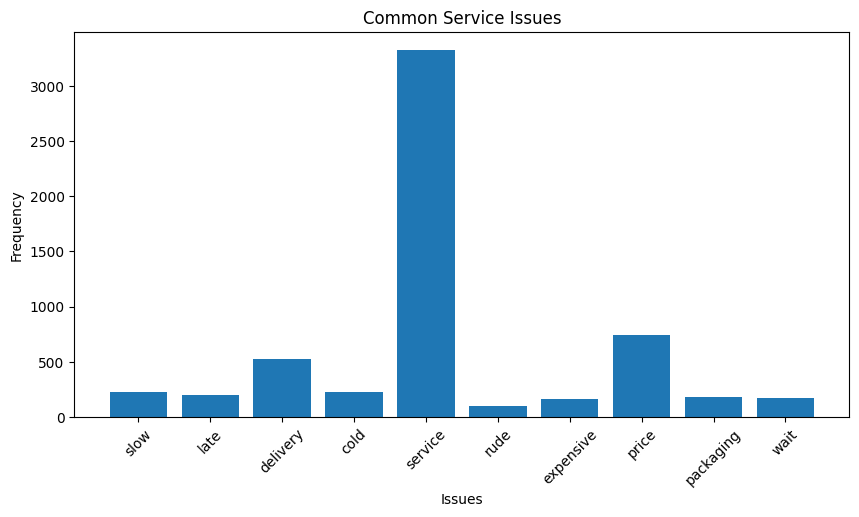

In [21]:
issue_counts = {}

for issue in issue_keywords:

    issue_counts[issue] = all_text.split().count(issue)

plt.figure(figsize=(10,5))

plt.bar(issue_counts.keys(),
        issue_counts.values())

plt.title("Common Service Issues")

plt.xlabel("Issues")

plt.ylabel("Frequency")

plt.xticks(rotation=45)

plt.show()

In [23]:
new_review = ["Food was delicious and service was excellent"]

new_review_clean = [clean_text(new_review[0])]

new_vector = tfidf.transform(new_review_clean)

prediction = model.predict(new_vector)

print("Predicted Sentiment:", prediction[0])

Predicted Sentiment: Positive
